In [1]:
# Annahmen
# Mehrfamilienhaus (Mfh) = 426 m^2 beheizte Wohnfläche (siehe Excel mit Quellen)
# Netto Trinkwarmwasserbedarf = 16,5 kWh/(m²*a)
# Anzahl Wohneinheiten = 6 --> 14,5 kW pro WE = 87 kW
# Installierbare PV-Leistung = 13 kWp (PV-Atlas)

# 3 Fälle je nach sanierungsgrad
# Fall 1: Ist-ZST (unsaniert)
# Netto Heizwärmebedarf  = 168,6	kWh/(m²*a)

# Fall 2: Konventionell (teilsaniert)
# Netto Heizwärmebedarf  = 82,5	kWh/(m²*a)

# Fall 3: zukunftsführend (vollständige Sanierung)
# Netto Heizwärmebedarf  = 25 kWh/(m²*a)





In [2]:
import pypsaheat as ph
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from datetime import datetime
from pathlib import Path
from datetime import datetime



C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\sarah\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


In [3]:
# ------------------------------------------------------------
# 1) Allgemeine Einstellungen
# ------------------------------------------------------------

# Wir simulieren ein Jahr in Stundenauflösung
N_HOURS = 8760
snapshots = range(N_HOURS)

# # HeatNetwork anlegen und Snapshots setzen
# n = ph.HeatNetwork()
# n.set_snapshots(snapshots)

In [4]:
# ------------------------------------------------------------
# Lasten laden
# ------------------------------------------------------------

# Fall auswählen (nur EINEN aktiv lassen)
# lastgang_file = "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_Ist_ZST.csv"
# lastgang_file = "./Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_konventionell.csv"
lastgang_file = "../Input_Data/2026-01-19-Mehrfamilienhaus-Lastprofile_zukunftsfuehrend.csv"

# Version automatisch aus Dateiname ableiten lassen
lf = lastgang_file.lower()
if "ist_zst" in lf:
    lastgang_version = "Ist_ZST"
elif "konventionell" in lf:
    lastgang_version = "konventionell"
elif "zukunft" in lf:
    lastgang_version = "zukunftsfuehrend"
else:
    lastgang_version = "unknown"

df = pd.read_csv(lastgang_file, sep=",", decimal=".")

# --- Zeitspalte finden ---
time_col = next((c for c in df.columns if "Zeit" in c), None)
if time_col is None:
    raise ValueError(f"Keine Zeitspalte gefunden. Spalten: {df.columns.tolist()}")

# --- Zeitspalte in datetime umwandeln ---
# falls bei dir sowas drinsteht wie "01-01 00:00" (TT-MM hh:mm), Jahr davor setzen:
df["Zeit"] = pd.to_datetime(
    "2019-" + df[time_col].astype(str),
    format="%Y-%d-%m %H:%M",
    errors="coerce"
)

# --- Index setzen ---
df = df.set_index("Zeit").sort_index()

print("Index-Typ:", type(df.index), "Min/Max:", df.index.min(), df.index.max())



Index-Typ: <class 'pandas.core.indexes.datetimes.DatetimeIndex'> Min/Max: 2019-01-01 00:00:00 2019-12-31 23:00:00


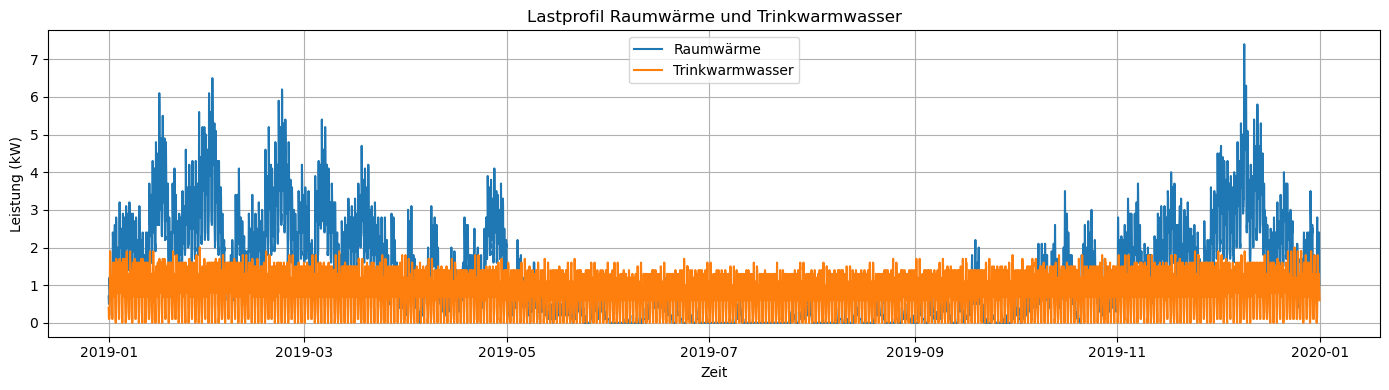

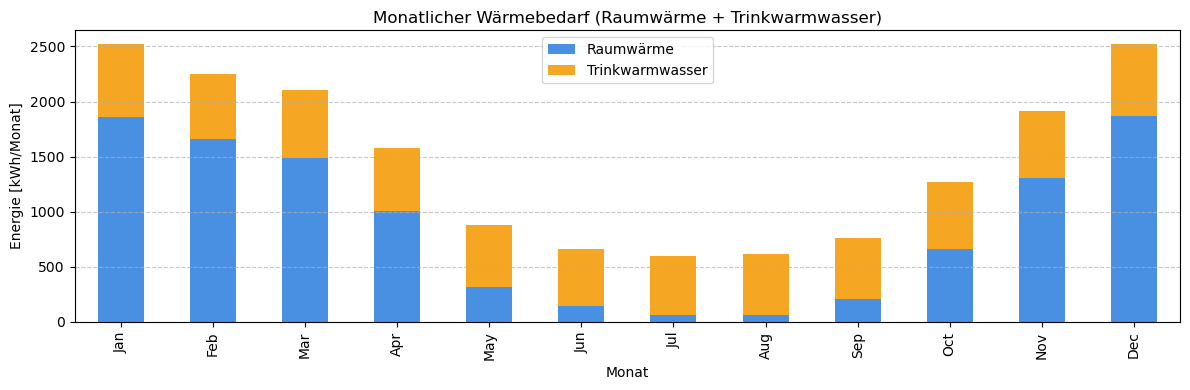

In [5]:
# ------------------------------------------------------------
# Plot der Lasten
# ------------------------------------------------------------

plt.figure(figsize=(14,4))
plt.plot(df.index, df["Raumwaerme_(kW)"], label="Raumwärme")
plt.plot(df.index, df["Trinkwarmwasser_(kW)"], label="Trinkwarmwasser")

plt.legend()
plt.title("Lastprofil Raumwärme und Trinkwarmwasser")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Monats-Balkendiagramm: Raumwärme + Trinkwarmwasser
# ------------------------------------------------------------

# Monatsenergie berechnen (kWh/Monat bei 1h-Zeitschritt)
monthly_heat = df.resample("ME")[[
    "Raumwaerme_(kW)",
    "Trinkwarmwasser_(kW)"
]].sum()

# Monatsnamen hübsch
monthly_heat.index = monthly_heat.index.strftime("%b")

# Plot
ax = monthly_heat.plot(
    kind="bar",
    stacked=True,
    figsize=(12,4),
    color=["#4A90E2", "#F5A623"]  # Blau = Raumwärme, Orange = TWW
)

ax.set_title("Monatlicher Wärmebedarf (Raumwärme + Trinkwarmwasser)")
ax.set_xlabel("Monat")
ax.set_ylabel("Energie [kWh/Monat]")
ax.legend(["Raumwärme", "Trinkwarmwasser"])
ax.grid(axis="y", alpha=0.7, linestyle="--")

plt.tight_layout()
plt.show()



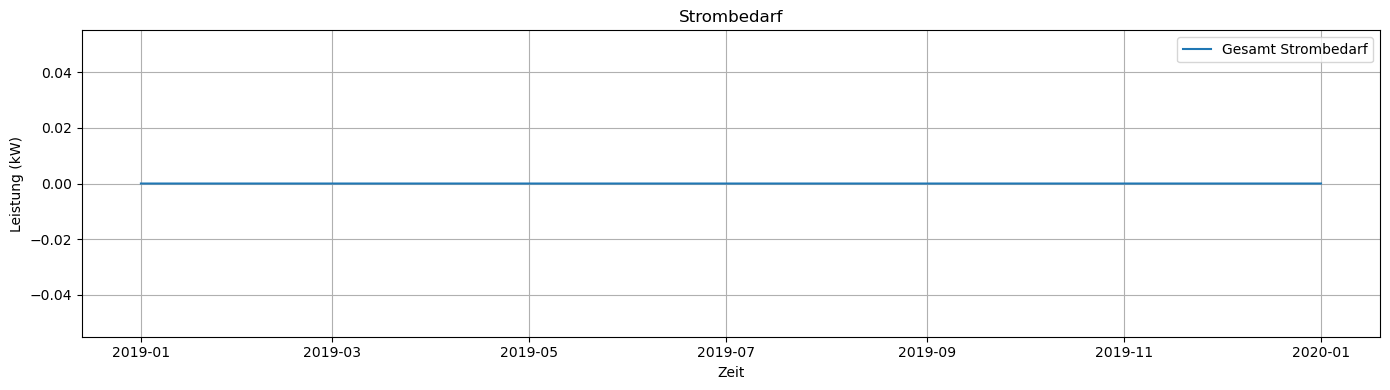

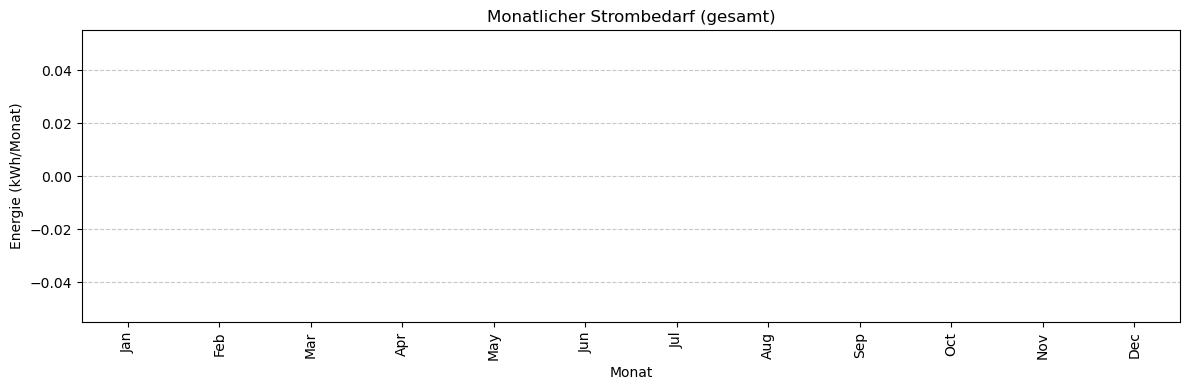

In [6]:
# ------------------------------------------------------------
# Plot der Nutzer Stromlast - momentan keine daten dazu im Lastprofil
# ------------------------------------------------------------

plt.figure(figsize=(14,4))
plt.plot(df.index, df["Strom_gesamt_(kW)"], label="Gesamt Strombedarf")

plt.legend()
plt.title("Strombedarf")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Monats-Balkendiagramm - Strom
# ------------------------------------------------------------

monthly_elec = df.resample("ME")[["Strom_gesamt_(kW)"]].sum()
monthly_elec.index = monthly_elec.index.strftime("%b")

ax = monthly_elec.plot(kind="bar", figsize=(12, 4), legend=False)
ax.set_title("Monatlicher Strombedarf (gesamt)")
ax.set_xlabel("Monat")
ax.set_ylabel("Energie (kWh/Monat)")
ax.grid(axis="y", alpha=0.7, linestyle="--")
plt.tight_layout()
plt.show()



In [7]:
# PV Erzeugungsprofil
# Annahmen: Dataset MERRA-2 (global), 2019, capacity 1kW, system loss 0.1 , Tilt 35°, Azimuth 180°, included raw data
pv = pd.read_csv(
    "../Input_Data/ninja_pv_50.9384_6.9600_corrected.csv",
    skiprows=3,
    parse_dates=["local_time"],
)

pv = pv.set_index("local_time")

pv = pv.rename(columns={
    "electricity": "pv_electricity",
    "irradiance_direct": "direct",
    "irradiance_diffuse": "diffuse",
    "temperature": "temp"
})

pv.head(100)

,time,pv_electricity,direct,diffuse,temp
local_time,,,,,
2019-01-01 01:00:00,2019-01-01 00:00,0.0,0.0,0.0,6.294
2019-01-01 02:00:00,2019-01-01 01:00,0.0,0.0,0.0,6.003
2019-01-01 03:00:00,2019-01-01 02:00,0.0,0.0,0.0,5.710
2019-01-01 04:00:00,2019-01-01 03:00,0.0,0.0,0.0,5.540
2019-01-01 05:00:00,2019-01-01 04:00,0.0,0.0,0.0,5.458
...,...,...,...,...,...
2019-01-05 00:00:00,2019-01-04 23:00,0.0,0.0,0.0,2.187
2019-01-05 01:00:00,2019-01-05 00:00,0.0,0.0,0.0,2.378
2019-01-05 02:00:00,2019-01-05 01:00,0.0,0.0,0.0,2.531


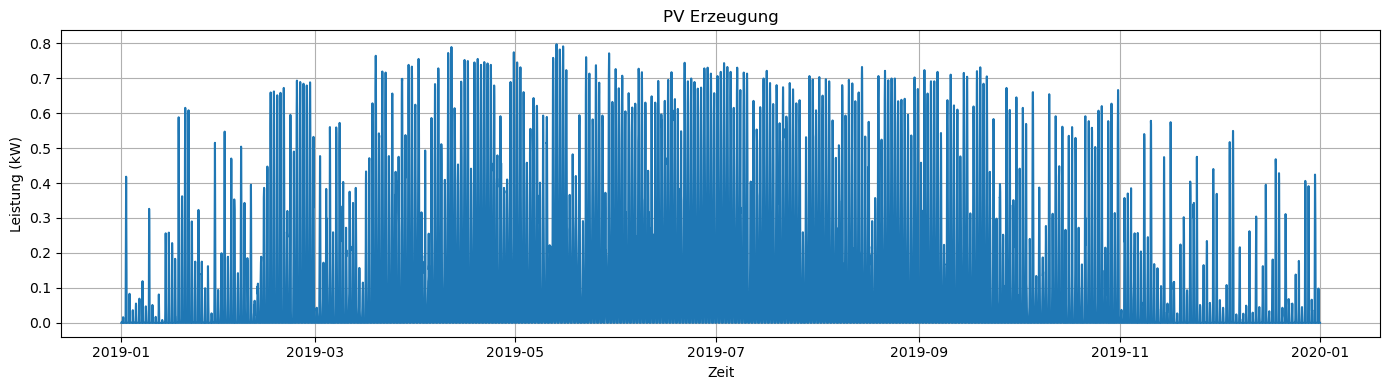

In [8]:
# Erzeugungsprofil PV plotten
plt.figure(figsize=(14,4))
plt.plot(pv.index, pv["pv_electricity"], label="PV (kW)")
plt.title("PV Erzeugung")
plt.xlabel("Zeit")
plt.ylabel("Leistung (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
# ------------------------------------------------------------
# Außentemperaturdaten laden
# ------------------------------------------------------------

weather = pd.read_csv(
    "../Input_Data/ninja_weather_50.9384_6.9600_2019_uncorrected.csv",
    skiprows=3,
    parse_dates=["local_time"]
)

# Index setzen
weather = weather.set_index("local_time")

# Umbenennen: t2m → T_outdoor
weather = weather.rename(columns={"t2m": "T_outdoor"})

# Nur Temperatur extrahieren
T_outdoor = weather["T_outdoor"]

T_outdoor.head()

local_time
2019-01-01 01:00:00    6.294
2019-01-01 02:00:00    6.003
2019-01-01 03:00:00    5.710
2019-01-01 04:00:00    5.540
2019-01-01 05:00:00    5.458
Name: T_outdoor, dtype: float64

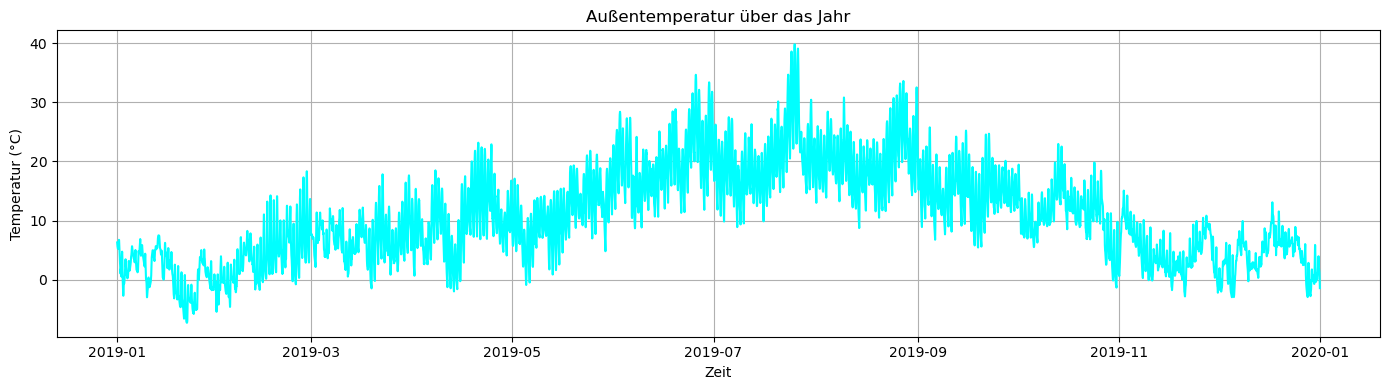

In [10]:
# -------------------------------------------
# Außentemperatur plotten
# -------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(weather.index, weather["T_outdoor"], label="Außentemperatur (°C)", color="cyan")

plt.title("Außentemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
### Auslegung der Komponenten
# Daten aus angehangen Quellen - Excel

In [12]:
#Strom
grid_power      =   87        # kW Hausanschluss Leistung
grid_cost       =   0.372     # €/kWh Kosten für Netzstrombezug

interest_rate = 0.02

# PV
pv_invest       =   731     # €/kWp (einmalig)
pv_lifetime     =   20      # Jahre
PV_power        =   13      # kWp
feed_in_tariff  =   -0.0778   # €/kWh

pv_annuity = pv_invest * ((1+interest_rate)**pv_lifetime) * interest_rate / ((1+interest_rate)**pv_lifetime - 1)


#Batterie
battery_invest           = 500     #€/kWh
#Battery_marginal_cost   = 0.0     # Grenzgestehungskosten für Batterie?
battery_lifetime         = 20      # Jahre
battery_annuity = battery_invest * ((1+interest_rate)**battery_lifetime) * interest_rate / ((1+interest_rate)**battery_lifetime - 1)


#Wärmespeicher - ggf. andere werte anpassen
store_height    =   2.15      #m
store_base      =   0.708     #m²
# Volumen = store_base * store_height = 1.52 m³
# wärmekapazität wasser = 1.16
#
store_u_wall    =   0.36      #W/(m²*K)
store_T_layers  =   [60, 54, 48, 42, 36, 30]      #°C Temperaturschichten; !
store_invest    =   1690      # €/kWh
store_lifetime  =   20       # Jahre
store_annuity   = store_invest * ((1+interest_rate)**store_lifetime) * interest_rate / ((1+interest_rate)**store_lifetime - 1)

# Wärmepumpe
# HP_power        =  35    #kW Wärmepumpenleistung - iterativ festlegen

TARGET = 0.90
HP_POWERS = range(10, 81, 5)  # z.B. 10..80 kW_th

Q_load = float(df["Raumwaerme_(kW)"].sum() + df["Trinkwarmwasser_(kW)"].sum())

def build_and_run(HP_power):
    # --- NEUES Network pro Run ---
    n = ph.HeatNetwork()
    n.set_snapshots(range(N_HOURS))

# Heizstab
HE_power        =   9      #kW Heizstableistung

# ------------------------------------------------------------
# Heizkörper vs. Fußbodenheizung über Heizkurve (flow_temperature)
# ------------------------------------------------------------

# Flag: True = Heizkörper, False = Fußbodenheizung
use_radiators = True

# HK T_vorlauf = 40 - 55 °C; FBH T_Vorlauf = 30-35 °C
T_vorlauf = 55.0 if use_radiators else 30.0         # 49 °C bei 0°C ; bzw 33 bei 0°C (nach Quelle - 30°C bei -10°C - 55° bei -10°C)
T_gradient = 9/15 if use_radiators else 3/15   # wie stark die Vorlauftemperatur mit der Außentemp. steigt/fällt

# Heizkurve berechnen (PyPSA_heat-Funktion)
T_flow = ph.physics.flow_temperature(T_vorlauf, T_gradient, T_outdoor)

delta_T = 10.0 if use_radiators else 5.0       # FBH hat geringere Rücklauftemperatur ~ %°C
store_T_return  = T_vorlauf - delta_T          # °C Rücklauftemperatur

heating_cutoff = 15.0                          # °C Außentemperatur, ab der nicht mehr geheizt wird
heat_on = T_outdoor <= heating_cutoff
T_flow_min = store_T_return + 3                # Mindestvorlauftemperatur (3°C über Rücklauftemp)
T_flow = T_flow.clip(lower=T_flow_min)
T_flow = T_flow.where(heat_on, T_flow_min)

T_flow


local_time
2019-01-01 01:00:00    51.22
2019-01-01 02:00:00    51.40
2019-01-01 03:00:00    51.57
2019-01-01 04:00:00    51.68
2019-01-01 05:00:00    51.73
                       ...  
2019-12-31 20:00:00    54.13
2019-12-31 21:00:00    54.31
2019-12-31 22:00:00    54.77
2019-12-31 23:00:00    55.34
2020-01-01 00:00:00    55.87
Name: T_outdoor, Length: 8760, dtype: float64

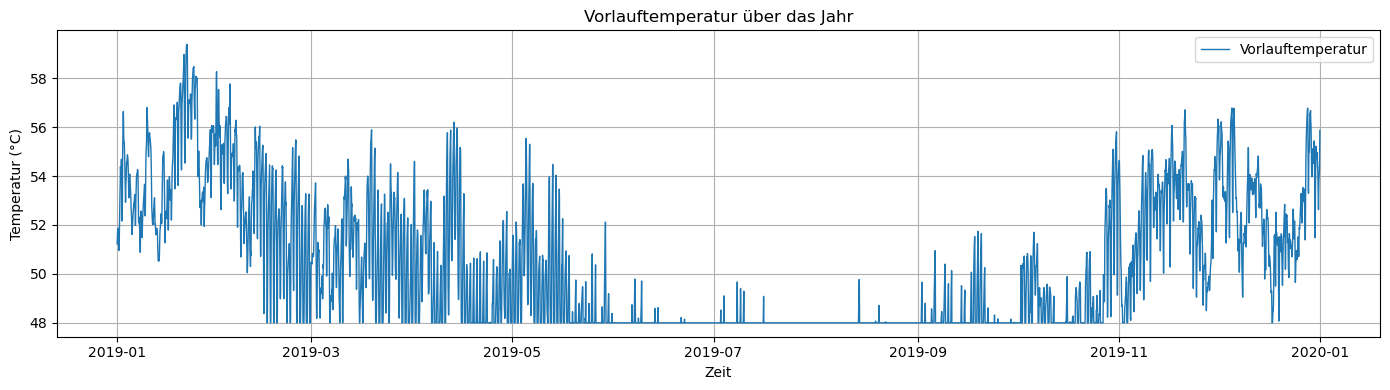

In [13]:
plt.figure(figsize=(14,4))
plt.plot(weather.index, T_flow, label="Vorlauftemperatur", linewidth=1)

plt.title("Vorlauftemperatur über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
TARGET = 0.90
HP_POWERS = range(10, 81, 5)

Q_load = float(df["Raumwaerme_(kW)"].sum() + df["Trinkwarmwasser_(kW)"].sum())

HE_power = 9  # bleibt fix

def build_and_run(HP_power):
    # --- NEUES Network pro Run ---
    n = ph.HeatNetwork()
    n.set_snapshots(range(N_HOURS))

    # ---------------------------------------------
    # Energiesystem bauen  (HIER MUSS ALLES EINGERÜCKT SEIN)
    # ---------------------------------------------

    # Busse
    n.add("Bus", "electricity_grid")
    n.add("Bus", "electricity_infeed")

    # grid import
    n.add("Generator", "grid_import", bus="electricity_grid", p_nom=grid_power, marginal_cost=grid_cost)

    # pv gen
    n.add("Generator", "pv_generation", bus="electricity_infeed",
          p_nom=PV_power, p_max_pu=pv["pv_electricity"].values, capital_cost=pv_annuity)

    # pv export sink
    n.add("Generator", "pv_infeed", bus="electricity_infeed",
          p_nom=PV_power, marginal_cost=feed_in_tariff, sign=-1)

    # link pv -> grid
    n.add("Link", "electricity_link", bus0="electricity_infeed", bus1="electricity_grid",
          p_nom=PV_power, efficiency=1.0)

    # battery
    n.add("StorageUnit", "store_el", bus="electricity_grid",
          e_nom_extendable=True, e_cyclic=True, standing_loss=0.01,
          capital_cost=battery_annuity, efficiency_store=0.95, efficiency_dispatch=0.95)

    # heat store
    n.add("HeatStore", "hs_mfh", constant="temperature",
          height=store_height, base=store_base,
          T_layer=store_T_layers, T_return=store_T_return,
          V_initial=[0,0,0,0,0,0], cyclic=True, T_amb=18.0, U_wall=store_u_wall)

    # heat pump  <<< HIER: p_nom=HP_power
    n.add("HeatPump", "hp_mfh",
          bus0="electricity_grid", heat_store="hs_mfh",
          p_nom=HP_power, T_source=T_outdoor.values, T_max=60, heat_source="air")

    # heating element
    n.add("HeatingElement", "backup_heater",
          bus0="electricity_grid", heat_store="hs_mfh",
          p_nom=HE_power, efficiency=0.95)

    # loads
    n.add("Load", "el_demand", bus="electricity_grid", p_set=df["Strom_gesamt_(kW)"].values)

    n.add("HeatLoad", "Raumwaerme", heat_store="hs_mfh",
          p_set=df["Raumwaerme_(kW)"].values, T_demand=T_flow.values)

    n.add("HeatLoad", "dhw", heat_store="hs_mfh",
          p_set=df["Trinkwarmwasser_(kW)"].values, T_demand=60.0)

    # optimize
    n.optimize(solver_name="gurobi")

    # --- Q_hp ---
    hp_name = "hp_mfh"
    hp_t = n.pnl("HeatPump")

    p_heat = hp_t.get("p_heat", None)
    if p_heat is None:
        raise KeyError("HeatPump panel hat keinen Key 'p_heat'. Verfügbare keys: " + str(list(hp_t.keys())))

    # Fall A: MultiIndex-Spalten (HeatPump, Temperature)
    if isinstance(p_heat, pd.DataFrame) and isinstance(p_heat.columns, pd.MultiIndex):
        if hp_name not in p_heat.columns.get_level_values(0):
            raise KeyError(f"'{hp_name}' nicht in p_heat MultiIndex vorhanden. level0: {p_heat.columns.get_level_values(0).unique().tolist()}")
        p_th_layers = p_heat.xs(hp_name, level=0, axis=1)     # -> DataFrame nur Temp-Layer
        p_th_total = p_th_layers.sum(axis=1)                  # -> Series Gesamtwärmeleistung pro Stunde

    # Fall B: normale Spalten (nur HeatPump-Namen)
    elif isinstance(p_heat, pd.DataFrame):
        if hp_name not in p_heat.columns:
            raise KeyError(f"'{hp_name}' nicht in p_heat columns vorhanden: {p_heat.columns.tolist()}")
        p_th_total = p_heat[hp_name]

    # Fall C: Series (eher selten)
    else:
        p_th_total = p_heat

    Q_hp = float(np.nansum(np.asarray(p_th_total, dtype=float)))


    # --- Q_he ---
    he_name = "backup_heater"
    heat_ts = None
    for k in ["p_heat", "p1", "p_out", "p"]:
        if k in n.heating_elements_t:
            heat_ts = n.heating_elements_t[k][he_name]
            break
    if heat_ts is None:
        raise KeyError("Kein passender Heat-Key in n.heating_elements_t gefunden.")
    Q_he = float(np.nansum(heat_ts.values))

    return n, Q_hp, Q_he



In [15]:
best = None
n_best = None

for HP_power in HP_POWERS:
    n_run, Q_hp, Q_he = build_and_run(HP_power)

    wp_share = Q_hp / Q_load if Q_load > 0 else np.nan
    he_share = Q_he / Q_load if Q_load > 0 else np.nan

    print(f"HP={HP_power:>3} kW_th | WP={wp_share*100:5.1f}% | HE={he_share*100:5.1f}%")

    if wp_share >= TARGET:
        best = HP_power
        n_best = n_run
        print(f"\nZiel erreicht: HP_power={HP_power} kW_th")
        break

if n_best is None:
    raise ValueError("Ziel nicht erreicht – HP_POWERS Range erhöhen.")

# --- ab hier: nur noch Auswertung/Plots mit n_best ---
n = n_best

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

C:\Users\sarah\anaconda3\Lib\site-packages\pypsa\components.py:836: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dty

Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2767106


INFO:gurobipy:Set parameter LicenseID to value 2767106


...

Solved in 99153 iterations and 2.93 seconds (1.62 work units)


INFO:gurobipy:Solved in 99153 iterations and 2.93 seconds (1.62 work units)


Optimal objective  2.607611671e+02


INFO:gurobipy:Optimal objective  2.607611671e+02
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 227760 primals, 455520 duals
Objective: 2.61e+02
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, StorageUnit-energy_balance, HeatStore-hs_mfh-fix-volume-upper, HeatStore-hs_mfh-fix-volume-lower, HeatStore-hs_mfh-layer_balance, HeatStore-hs_mfh-internal-lower, HeatingElement-backup_heater-fix-p-lower, HeatingElement-backup_heater-fix-p-upper, HeatPump-hp_mfh-fix-p-lower, HeatPump-hp_mfh-fix-p-upper, HeatPump-hp_mfh-fix-p-layer-lower, HeatPump-hp_mfh-fix-p-layer-upper were not assigned to the

HP= 10 kW_th | WP=102.4% | HE=  0.1%

Ziel erreicht: HP_power=10 kW_th


In [16]:
hp_t = n.pnl("HeatPump")
print("hp_t keys:", list(hp_t.keys()))

p_heat = hp_t.get("p_heat", None)
print("type(p_heat):", type(p_heat))

if hasattr(p_heat, "columns"):
    print("p_heat columns type:", type(p_heat.columns))
    print("p_heat columns sample:", list(p_heat.columns)[:6])


hp_t keys: ['p_heat', 'p_elec', 'm_flow', 'T_source', 'COP', 'hp_mfh-p']
type(p_heat): <class 'pandas.core.frame.DataFrame'>
p_heat columns type: <class 'pandas.core.indexes.multi.MultiIndex'>
p_heat columns sample: [('hp_mfh', 60), ('hp_mfh', 54), ('hp_mfh', 48), ('hp_mfh', 42), ('hp_mfh', 36), ('hp_mfh', 30)]


In [17]:
# ============================================================
# Energiesystem: Ergebnisse & Kennzahlen
# ============================================================

print("====================================")
print("Energiesystem – Überblick")
print("====================================")

# ------------------------------------------------------------
# 1) Komponenten-Auslegung (Nennleistungen)
# ------------------------------------------------------------

print("\n--- Komponenten ---")

# Generatoren (klassisch)
if "pv_generation" in n.generators.index:
    print("PV Leistung [kW]:", n.generators.loc["pv_generation", "p_nom"])

if "grid_import" in n.generators.index:
    print("Netzanschluss [kW]:", n.generators.loc["grid_import", "p_nom"])

# PyPSA-Heat Komponenten (generic API)
hp_df = n.df("HeatPump")
he_df = n.df("HeatingElement")
hs_df = n.df("HeatStore")

if "hp_mfh" in hp_df.index:
    # je nach Version p_nom oder p_nom_opt (wenn extendable)
    if "p_nom_opt" in hp_df.columns:
        print("Wärmepumpe Leistung [kW_th]:", hp_df.loc["hp_mfh", "p_nom_opt"])
    else:
        print("Wärmepumpe Leistung [kW_th]:", hp_df.loc["hp_mfh", "p_nom"])

if "backup_heater" in he_df.index:
    if "p_nom_opt" in he_df.columns:
        print("Heizstab Leistung [kW_el]:", he_df.loc["backup_heater", "p_nom_opt"])
    else:
        print("Heizstab Leistung [kW_el]:", he_df.loc["backup_heater", "p_nom"])

# Wärmespeicher-Auslegung (Geometrie / Dämmung)
if "hs_mfh" in hs_df.index:
    print("\n--- Wärmespeicher (hs_mfh) ---")
    for col in ["height", "base", "U_wall", "T_return", "T_amb"]:
        if col in hs_df.columns:
            print(f"{col}: {hs_df.loc['hs_mfh', col]}")


Energiesystem – Überblick

--- Komponenten ---
PV Leistung [kW]: 13.0
Netzanschluss [kW]: 87.0
Wärmepumpe Leistung [kW_th]: 10.0
Heizstab Leistung [kW_el]: 9.0

--- Wärmespeicher (hs_mfh) ---
height: 2.15
base: 0.708
U_wall: 0.36
T_return: 45.0
T_amb: 18.0


In [18]:
# Batteriedaten abfragen:

print("StorageUnits vorhanden:", getattr(n, "storage_units", pd.DataFrame()).index.tolist())

if "store_el" in getattr(n, "storage_units", pd.DataFrame()).index:
    print("\nstore_el Parameter:")
    print(n.storage_units.loc["store_el"])
    print("\nstore_el dispatch time series vorhanden?:",
          "store_el" in getattr(n, "storage_units_t", pd.DataFrame()).p.columns)
else:
    print("store_el ist nicht im Network gelandet.")

StorageUnits vorhanden: ['store_el']

store_el Parameter:
attribute
bus                                   electricity_grid
control                                             PQ
type                                                  
p_nom                                              0.0
p_nom_mod                                          0.0
p_nom_extendable                                 False
p_nom_min                                          0.0
p_nom_max                                          inf
p_min_pu                                          -1.0
p_max_pu                                           1.0
p_set                                              0.0
q_set                                              0.0
sign                                               1.0
carrier                                               
marginal_cost                                      0.0
marginal_cost_quadratic                            0.0
capital_cost                                 30.5783


Wärmepumpe – Auswertung (hp_mfh)


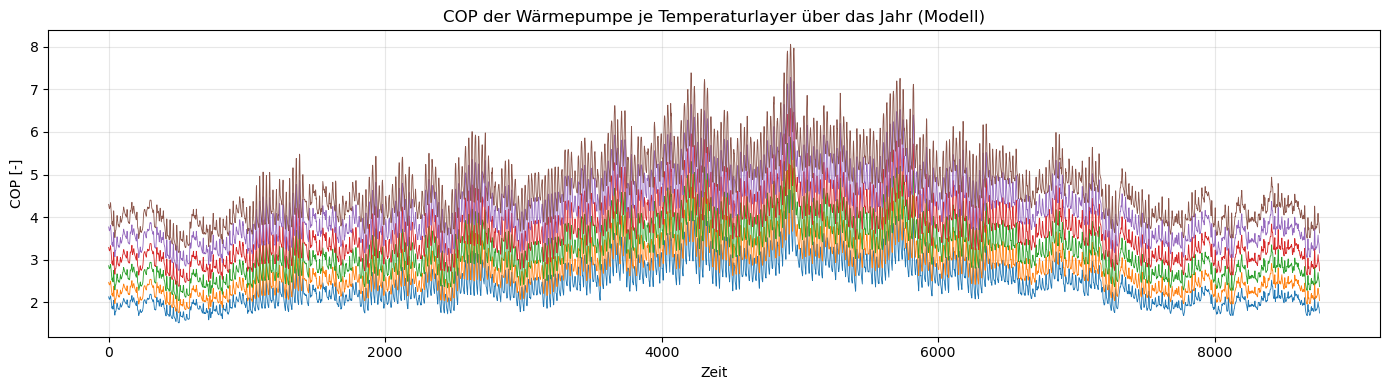


--- Auslegung ---
Thermische Nennleistung p_nom: 10.00 kW_th

--- COP Kennzahlen (physikalisch = p_heat/p_elec) ---
COP Mittelwert: 2.84
COP Median:     2.65
COP Minimum:    1.53
COP Maximum:    6.31

--- Jahresenergien ---
WP Stromverbrauch: 7339.49 kWh_el/a
WP Wärmeerzeugung: 18071.40 kWh_th/a

--- JAZ ---
JAZ_HP (Q_hp / E_hp): 2.462


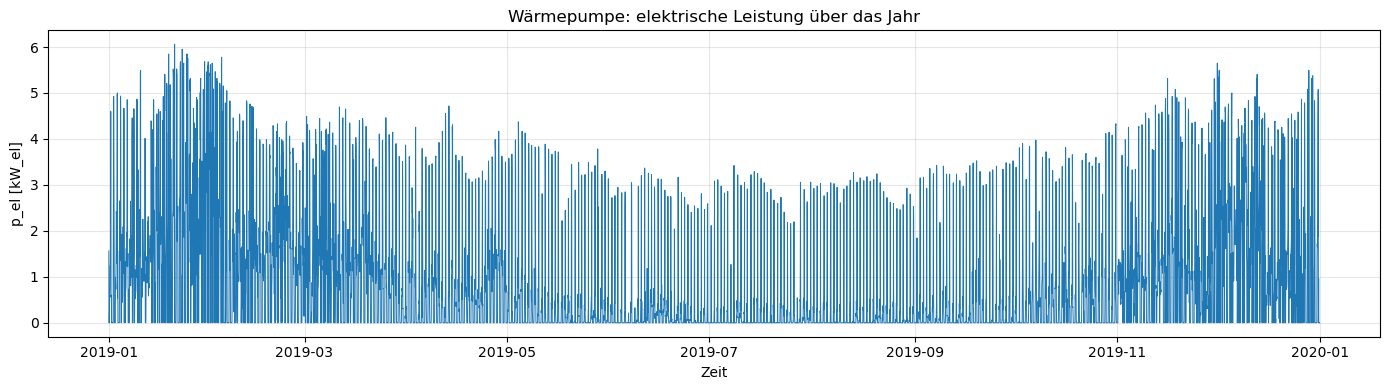

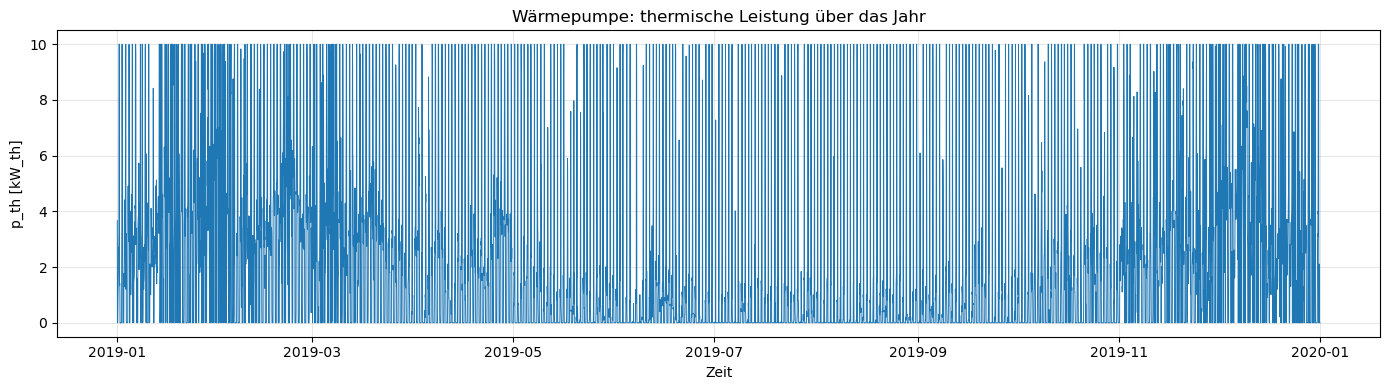

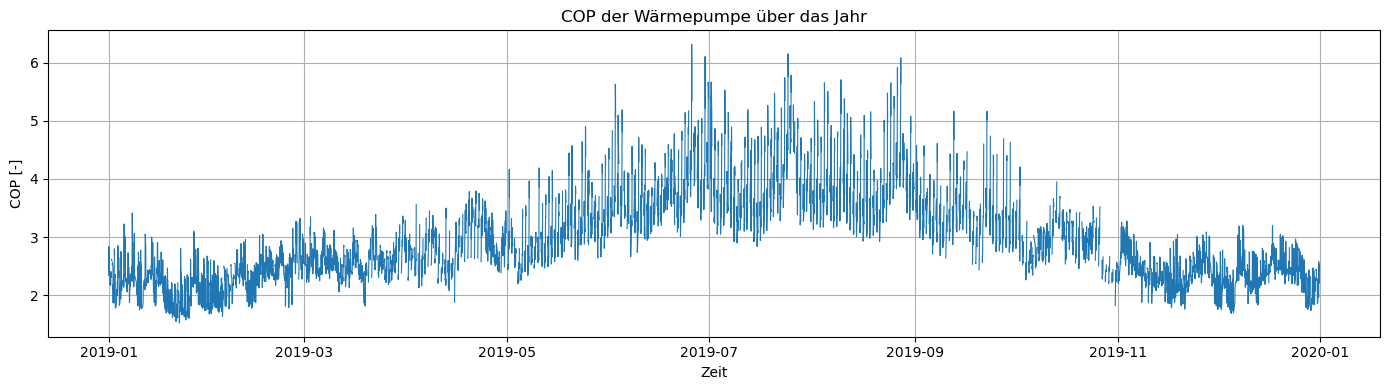

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


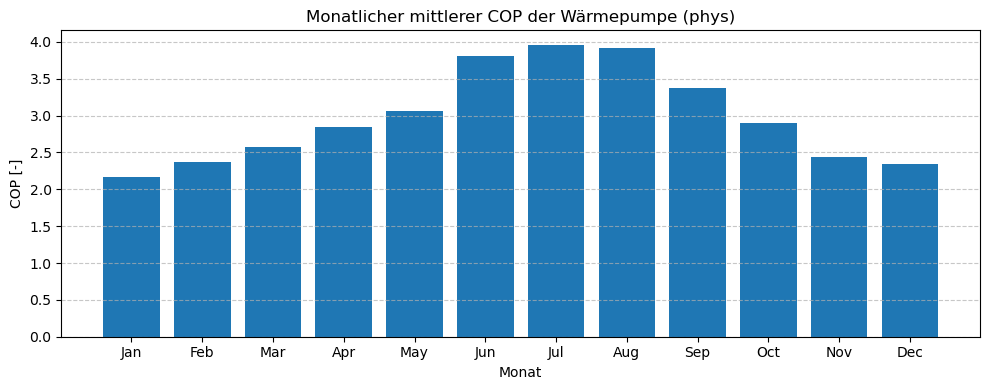

In [19]:
# ============================================================
# Wärmepumpe (hp_mfh): Kennzahlen, COP-Verlauf, JAZ (Layer-korrekt)
# ============================================================
# noch ausgeben lassen wie viel % der Wärme die WP abdeckt und wie viel % der Heizstab!!!

hp_name = "hp_mfh"

hp_df = n.df("HeatPump")        # Tabelle Parameter HP
hp_t  = n.pnl("HeatPump")       # Zeitreihen-Container pro Std. für HP (p_heat, p_elec, COP)

# hp_t =
#   "p_heat":  Zeitreihe(n),
#   "p_elec":  Zeitreihe(n),
#   "COP":     Zeitreihe(n),
#   ...
#   }

print("\n====================================")
print(f"Wärmepumpe – Auswertung ({hp_name})")
print("====================================")

# --- Modellergebnisse der WP  ---
cop_model  = hp_t["COP"][hp_name]         # kommt aus unserem Model und kann mehere Temperaturschichten enthalten
p_el_model = hp_t["p_elec"][hp_name]      # p_el_model = elektrische Leistung der WP
p_th_model = hp_t["p_heat"][hp_name]      # p_th_model = thermische Leistung der WP

# ============================================================
# kurzer Einschub Plot: COP je Temperaturlayer darstellen
# ============================================================

plt.figure(figsize=(14,4))

if isinstance(cop_model, pd.DataFrame):
    # Mehrere Temperaturlayer → jede Spalte wird eine Linie
    plt.plot(cop_model.index, cop_model.values, linewidth=0.6)
    plt.title("COP der Wärmepumpe je Temperaturlayer über das Jahr (Modell)")
else:
    # Nur ein Layer
    plt.plot(cop_model.index, cop_model.values, linewidth=0.8)
    plt.title("COP der Wärmepumpe über das Jahr (Modell)")

plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# ============================================================
# jetzt weiter mit Code
# ============================================================


# --- Zeitindex (für Plot & Resample) ---
time_index = pd.DatetimeIndex(df.index)

# p_heat / p_elec: Gesamtleistung (Summe über Layer, falls nötig)

# Typabfrage mit isinstance(..) = ist p_th_model ein DataFrame (mehere Layer)
# wenn p_th_model ein DataFrame ist, dann summe über alle Layer, sonst nur über 1. Layer - damit # der Layer anpassbar
p_th_total = p_th_model.sum(axis=1) if isinstance(p_th_model, pd.DataFrame) else p_th_model
p_el_total = p_el_model.sum(axis=1) if isinstance(p_el_model, pd.DataFrame) else p_el_model

# optional: Modell-COP als Mittel (nur Info)
# mean(axis=1) bedutet arithmetischer Mittelwert aller Layer-COPs pro Stunde
# Das ist der gemittelte Modell-COP über alle Temperaturschichten.
# cop_model_mean ist der aus dem Modell resultierende, über alle Temperaturlayer gemittelte COP und dient ausschließlich der qualitativen Interpretation, nicht der energetischen Bewertung.
cop_model_mean = cop_model.mean(axis=1) if isinstance(cop_model, pd.DataFrame) else cop_model

# Datetime-Series
# p_el_s = die stündliche elektrische Leistung der WP
# np.asarray(p_el_s, dtype=float) erzwingt numpy-Array-Konvertierung (robuste Statistik)
# pd.series baut daraus eine Zeitreihe - jeder Wert bekommt einen Zeitstempel aus dem time_index
# „Ich nehme Daten aus der Simulation und mache daraus eine saubere, zeitlich zuordenbare Serie.“
# p_el_ts = elektrische Leistung der Wp pro std in pd.series
p_el_ts = pd.Series(np.asarray(p_el_total, dtype=float), index=time_index)
p_th_ts = pd.Series(np.asarray(p_th_total, dtype=float), index=time_index)
cop_model_ts = pd.Series(np.asarray(cop_model_mean, dtype=float), index=time_index)

# Physikalischer COP aus Q/P
# Betriebs COP der WP pro stunde
# p_th_ts = Wärmeleistung der WP (kW_th) pro Stunde
# p_el_ts = Elektrische Leistung der WP (kW_el) pro Stunde
# p_el_ts.replace(0, np.nan) = ersetzt alle Stellen, wo der Stromverbrauch 0 ist, durch NaN.
cop_phys_ts = p_th_ts / p_el_ts.replace(0, np.nan)

# --- Auslegung ---
# wenn es die Spalte p_nom gibt → Wert auslesen
# sonst → None, Schutz falls das Modell p_nom nicht gesetzt ist
P_th_nom_val = float(hp_df.loc[hp_name, "p_nom"]) if "p_nom" in hp_df.columns else None
print("\n--- Auslegung ---")
if P_th_nom_val is not None:
    print(f"Thermische Nennleistung p_nom: {P_th_nom_val:.2f} kW_th")

# --- Kennzahlen (COP phys) ---
# np.nanmean(...), np.nanmedian(...), etc. sind numpy-Funktionen
# float() wandelt Ergebnis in Python Scalar für print(..), weiterrechnen usw.
COP_mean   = float(np.nanmean(cop_phys_ts.values))      # Durchschnittlicher Betriebs-COP
COP_median = float(np.nanmedian(cop_phys_ts.values))    # Median-Betriebs-COP
COP_min    = float(np.nanmin(cop_phys_ts.values))       # Schlechtester Betriebszustand
COP_max    = float(np.nanmax(cop_phys_ts.values))       # Bester Betriebszustand

print("\n--- COP Kennzahlen (physikalisch = p_heat/p_elec) ---")
print(f"COP Mittelwert: {COP_mean:.2f}")
print(f"COP Median:     {COP_median:.2f}")
print(f"COP Minimum:    {COP_min:.2f}")
print(f"COP Maximum:    {COP_max:.2f}")

# --- Jahresenergien ---
E_hp = float(np.nansum(p_el_ts.values))  # kWh_el/a
Q_hp = float(np.nansum(p_th_ts.values))  # kWh_th/a
# .values → NumPy-Array der Zahlen, np.nansum(...) → summiert alles, ignoriert NaNs, float(...) → macht daraus eine normale Zahl

print("\n--- Jahresenergien ---")
print(f"WP Stromverbrauch: {E_hp:.2f} kWh_el/a")
print(f"WP Wärmeerzeugung: {Q_hp:.2f} kWh_th/a")

# --- JAZ Berechnung ---
print("\n--- JAZ ---")
JAZ_hp = (Q_hp / E_hp) if E_hp > 0 else np.nan
print(f"JAZ_HP (Q_hp / E_hp): {JAZ_hp:.3f}")


# --- Ergebnis Plots:  ---

# Wärmepumpe: elektrische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_el_ts.index, p_el_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: elektrische Leistung über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("p_el [kW_el]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: thermische Leistung über das Jahr
plt.figure(figsize=(14,4))
plt.plot(p_th_ts.index, p_th_ts.values, linewidth=0.7)
plt.title("Wärmepumpe: thermische Leistung über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("p_th [kW_th]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Wärmepumpe: Betriebs COP über das Jahr
plt.figure(figsize=(14,4))
plt.plot(cop_phys_ts.index, cop_phys_ts.values, linewidth=0.8, label="COP phys (Q/P)")
plt.title("COP der Wärmepumpe über das Jahr")
plt.xlabel("Zeit")
plt.ylabel("COP [-]")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Monatsmittel COP (phys) ---
cop_monthly = cop_phys_ts.resample("ME").mean()
cop_monthly.index = cop_monthly.index.strftime("%b")

plt.figure(figsize=(10,4))
plt.bar(cop_monthly.index, cop_monthly.values)
plt.title("Monatlicher mittlerer COP der Wärmepumpe (phys)")
plt.xlabel("Monat")
plt.ylabel("COP [-]")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()





In [20]:
hp_df = n.df("HeatPump")
print(hp_df.columns)
print(hp_df.loc["hp_mfh"])


Index(['bus0', 'heat_store', 'type', 'carrier', 'p_nom', 'm_nom', 'T_source',
       'T_nom', 'T_max', 'COP_model', 'heat_source'],
      dtype='object', name='attribute')
attribute
bus0           electricity_grid
heat_store               hs_mfh
type                           
carrier                        
p_nom                      10.0
m_nom                       0.0
T_source                    0.0
T_nom                      60.0
T_max                      60.0
COP_model                   0.0
heat_source                 air
Name: hp_mfh, dtype: object


heating_elements_t keys: ['p', 'p_heat', 'p_elec']

--- Peaks ---
max p_heat [kW]: 2.5763490802402105
max p_elec [kW]: 2.7119464002528533


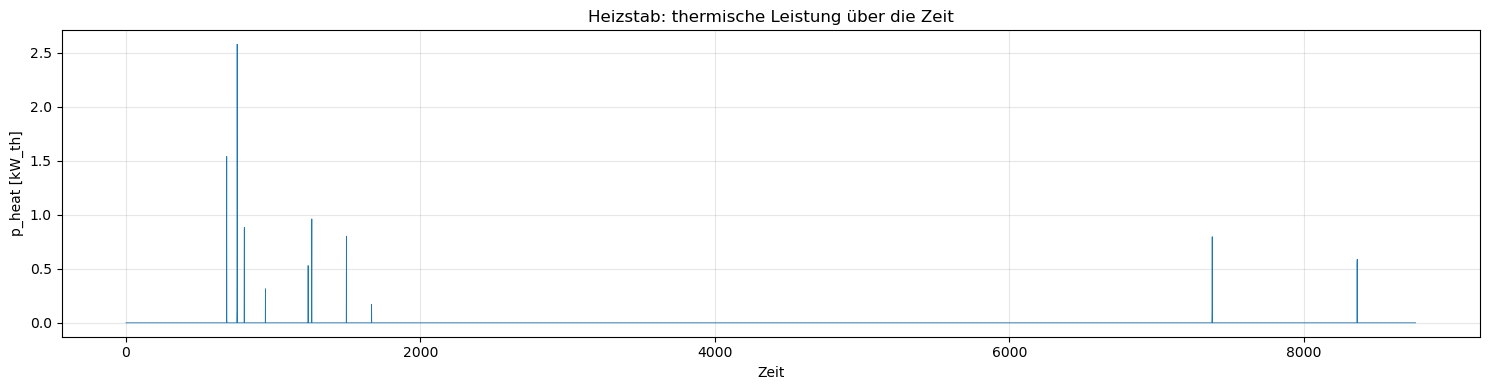

In [21]:
# ---------------------------------------
# Heizstab-Auswertung (backup_heater)
# ---------------------------------------

name = "backup_heater"

# verfügbare Keys anschauen
print("heating_elements_t keys:", list(n.heating_elements_t.keys()))

# helper: erste passende Zeitreihe nehmen
def get_ts(d, candidates):
    for c in candidates:
        if c in d:
            return d[c]
    raise KeyError(f"Keiner der Keys {candidates} in heating_elements_t vorhanden.")

# Kandidaten für "thermische Leistung" und "elektrische Leistung"
heat_key = get_ts(n.heating_elements_t, ["p_heat", "p1", "p_out", "p"])
elec_key = get_ts(n.heating_elements_t, ["p_elec", "p0", "p_in"])

# Das sind DataFrames → Spalte auswählen
p_heat = heat_key[name]
p_elec = elec_key[name]

print("\n--- Peaks ---")
print("max p_heat [kW]:", float(p_heat.max()))
print("max p_elec [kW]:", float(p_elec.max()))

# electrisch im jahr genutzt
# thermisch im jahr produziert

# Plot
plt.figure(figsize=(15,4))
plt.plot(p_heat.index, p_heat.values, linewidth=0.6)
plt.title("Heizstab: thermische Leistung über die Zeit")
plt.xlabel("Zeit")
plt.ylabel("p_heat [kW_th]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [22]:
# ============================================================
# Deckungsanteile Wärmeerzeuger (WP vs. Heizstab)
# ============================================================

# Heizstab: Jahreswärme
Q_he = float(np.nansum(p_heat.values))   # kWh_th/a

# WP: Jahreswärme (hast du schon)
Q_wp = float(Q_hp)                       # kWh_th/a

Q_total = Q_wp + Q_he

wp_share = (Q_wp / Q_total) * 100 if Q_total > 0 else np.nan
he_share = (Q_he / Q_total) * 100 if Q_total > 0 else np.nan

print("\n====================================")
print("Deckungsanteile Wärmeerzeugung")
print("====================================")
print(f"Wärmepumpe: {wp_share:.2f} %")
print(f"Heizstab:   {he_share:.2f} %")
print(f"Gesamtwärme: {Q_total:.0f} kWh_th/a")



Deckungsanteile Wärmeerzeugung
Wärmepumpe: 99.92 %
Heizstab:   0.08 %
Gesamtwärme: 18086 kWh_th/a



--- Strombilanz ---
Verbrauch gesamt (HH+WP+HE+BattLaden): 7355 kWh/a
Netzbezug:                             3002 kWh/a
PV-Erzeugung:                          15355 kWh/a
Einspeisung (Export):                  -11002 kWh/a
Batterie Laden:                        0 kWh/a
Batterie Entladen:                     0 kWh/a
Autarkiegrad:                          59.2 %


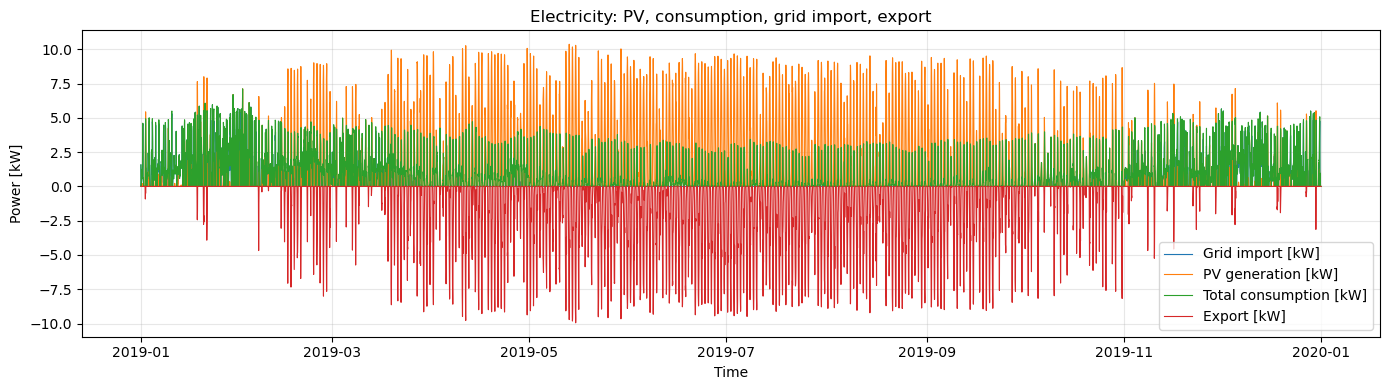

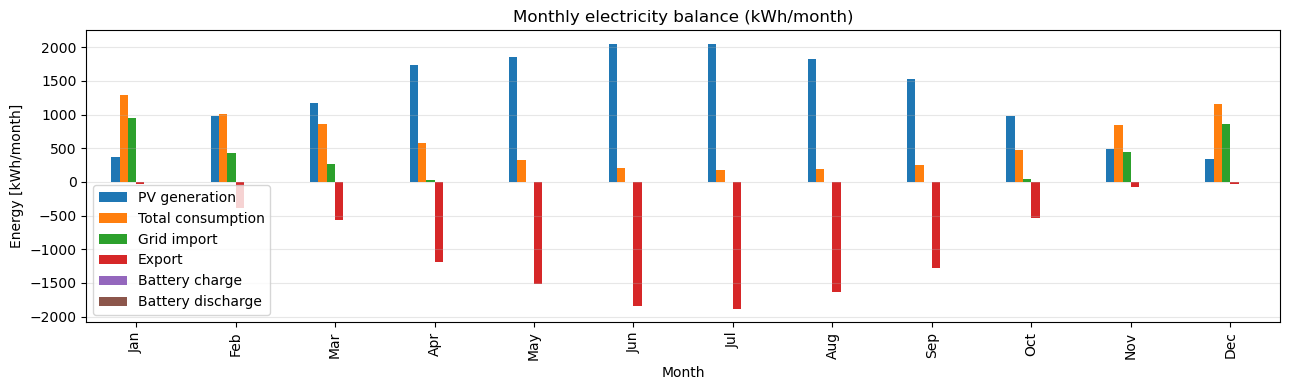

In [23]:
# ================================
#  Strombilanz - Netzbezug - PV Gen. - Einspeisung etc.
# ================================

time_index = pd.DatetimeIndex(df.index)

# --- 1) PV generation (kW) ---
pv_gen = n.generators_t.p["pv_generation"]  # kW, >=0

# --- 2) Grid import (kW) ---
grid_import = n.generators_t.p["grid_import"]  # kW, >=0

# --- 3) Feed-in / export (kW, make it positive) ---
if "pv_infeed" in n.generators_t.p.columns:
    export = -n.generators_t.p["pv_infeed"]     # kW, >=0
else:
    export = pd.Series(0.0, index=n.snapshots)

# --- 4) Household electric load (kW) ---
load_el = n.loads_t.p["el_demand"]  # kW

# --- 5) Heat pump electric consumption (kW) ---
hp_t = n.pnl("HeatPump")
hp_p_el = hp_t["p_elec"]["hp_mfh"]
hp_p_el_total = hp_p_el.sum(axis=1) if isinstance(hp_p_el, pd.DataFrame) else hp_p_el  # kW

# --- 6) Heating element electric consumption (kW) ---
he_t = n.pnl("HeatingElement")
he_p_el = he_t["p_elec"]["backup_heater"]
he_p_el_total = he_p_el.sum(axis=1) if isinstance(he_p_el, pd.DataFrame) else he_p_el  # kW

# --- 7) Battery (kW): StorageUnit p > 0 discharges to bus, p < 0 charges from bus ---
if "store_el" in getattr(n, "storage_units", pd.DataFrame()).index and \
   "store_el" in getattr(n, "storage_units_t", pd.DataFrame()).p.columns:
    bat_p = n.storage_units_t.p["store_el"]  # kW
    bat_charge = (-bat_p).clip(lower=0)      # kW charging
    bat_discharge = (bat_p).clip(lower=0)    # kW discharging
else:
    bat_charge = pd.Series(0.0, index=n.snapshots)
    bat_discharge = pd.Series(0.0, index=n.snapshots)

# --- Total electric consumption on the grid bus (kW) ---
# This is what must be covered by PV (via link), battery discharge, and grid import.
total_consumption = load_el + hp_p_el_total + he_p_el_total + bat_charge

# --- Energies (kWh) for hourly data: sum of kW values ---
E_grid = float(grid_import.sum())
E_cons = float(total_consumption.sum())
E_pv = float(pv_gen.sum())
E_exp = float(export.sum())
E_bat_chg = float(bat_charge.sum())
E_bat_dis = float(bat_discharge.sum())

autarkiegrad = 1 - (E_grid / E_cons) if E_cons > 0 else np.nan

print("\n--- Strombilanz ---")
print(f"Verbrauch gesamt (HH+WP+HE+BattLaden): {E_cons:.0f} kWh/a")
print(f"Netzbezug:                             {E_grid:.0f} kWh/a")
print(f"PV-Erzeugung:                          {E_pv:.0f} kWh/a")
print(f"Einspeisung (Export):                  {E_exp:.0f} kWh/a")
print(f"Batterie Laden:                        {E_bat_chg:.0f} kWh/a")
print(f"Batterie Entladen:                     {E_bat_dis:.0f} kWh/a")
print(f"Autarkiegrad:                          {autarkiegrad*100:.1f} %")

# --- Plot: power time series ---
plt.figure(figsize=(14,4))
plt.plot(time_index, grid_import.values, label="Grid import [kW]", linewidth=0.8)
plt.plot(time_index, pv_gen.values, label="PV generation [kW]", linewidth=0.8)
plt.plot(time_index, total_consumption.values, label="Total consumption [kW]", linewidth=0.8)
plt.plot(time_index, export.values, label="Export [kW]", linewidth=0.8)
plt.title("Electricity: PV, consumption, grid import, export")
plt.xlabel("Time")
plt.ylabel("Power [kW]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Monthly energy bars (kWh/month) ---
pv_ts   = pd.Series(pv_gen.to_numpy(), index=time_index)
cons_ts = pd.Series(total_consumption.to_numpy(), index=time_index)
imp_ts  = pd.Series(grid_import.to_numpy(), index=time_index)
exp_ts  = pd.Series(export.to_numpy(), index=time_index)
chg_ts  = pd.Series(bat_charge.to_numpy(), index=time_index)
dis_ts  = pd.Series(bat_discharge.to_numpy(), index=time_index)

monthly = pd.DataFrame({
    "PV generation":     pv_ts.resample("ME").sum(),
    "Total consumption": cons_ts.resample("ME").sum(),
    "Grid import":       imp_ts.resample("ME").sum(),
    "Export":            exp_ts.resample("ME").sum(),
    "Battery charge":    chg_ts.resample("ME").sum(),
    "Battery discharge": dis_ts.resample("ME").sum(),
})
monthly.index = monthly.index.strftime("%b")

ax = monthly.plot(kind="bar", figsize=(13,4))
ax.set_title("Monthly electricity balance (kWh/month)")
ax.set_xlabel("Month")
ax.set_ylabel("Energy [kWh/month]")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [24]:
print("Objective (total system cost):", n.objective)
print("Capital expenditures (CAPEX):", n.statistics.capex())
print("Operational expenditures (OPEX):", n.statistics.opex())
grid_costs_total = grid_cost * E_grid
print("Gridcosts", grid_cost * E_grid)
costs_total = n.objective + grid_costs_total
print("Total costs", costs_total)

Objective (total system cost): 260.7611671181753
Capital expenditures (CAPEX): component  carrier
Generator  -          581.17229
dtype: float64
Operational expenditures (OPEX): component  carrier
Generator  -          260.76117
dtype: float64
Gridcosts 1116.691136075977
Total costs 1377.4523031941524


In [25]:
warmegesthehungskosten = costs_total / Q_hp     # Heizstab noch hinzu
print(f"Wärmegestehungskosten: {warmegesthehungskosten:.2f} €/kWh_th")


Wärmegestehungskosten: 0.08 €/kWh_th


In [26]:
# # ============================================================
# # Ergebnis-CSV
# # ============================================================
#
# scenario_id = f"{lastgang_version}__Tv{int(T_vorlauf)}__{'HK' if use_radiators else 'FBH'}"
# # z.B. "ist_zst__Tv55__HK"
#
# results_row = {
#     "scenario_id": scenario_id,
#     "lastgang_version": lastgang_version,
#     "lastgang_file": lastgang_file,
#     "use_radiators": use_radiators,
#     "T_vorlauf_C": float(T_vorlauf),
#     "JAZ_wp": float(JAZ_hp),
#     "WP_Nennleistung": float(HP_power),
#     "WP_Deckungsanteil": float(wp_share),
#     "HE_Nennleistung": float(HE_power),
#     "HE_Deckungsanteil": float(he_share),
#     "waermegestehungskosten_EUR_per_kWh_th": float(warmegesthehungskosten),
#     "Total_costs_€/a": float(n.objective),
#     "CAPEX_€/a": float(n.statistics.capex()),
#     "OPEX_€/a": float(n.statistics.opex()),
#     "grid_import_kWh": float(E_grid),
#     "Q_hp_kWh_th": float(Q_hp),
#     "E_hp_kWh_el": float(E_hp),
# }
#
# BASE_DIR = Path.cwd()
#
# results_dir = BASE_DIR / "Output" / "sensitivity_runs"
# results_dir.mkdir(parents=True, exist_ok=True)
#
# results_path = results_dir / f"results_{scenario_id}.csv"
#
# df_out = pd.DataFrame([results_row])
# df_out.to_csv(results_path, index=False)
#
# print(f"\n Neue Datei pro Run gespeichert in:\n{results_path.resolve()}")


In [27]:
# Fragen:
# - soll im sommer über heating cut off - 15 °C nicht mehr geheizt werden? momentan wird die vorlauftemp auf konstantem wert gehalten
# - store return - müsste das nicht mehere werte übers jahr sein - abhängig von der vorlauftemp sein und nicht ein konstanter wert sein?
# - Wärmepumpe p_nom_extendable true? - schleife das so viele runs gemacht werden bis die WP mind 90% des Wärmebedarfs deckt
# - Für varriation FBH und HK auch varriation in Schichten
# - Investitionskosten?